In [72]:
%reload_ext autoreload
%autoreload 2

import os, glob, sys
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib as mpl
from rsg import rsg_phot
from dust import dusty_gen
from tqdm import tqdm
import copy
import pandas as pd
%matplotlib inline

### MARCS models

In [54]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(6.0, 4.4 * u.Lsun, 3500 * u.K, 800 * u.K, 13.0 * u.Mpc, 'g2')
filts = ['f090w', 'f115w', 'f150w', 'f164n', 'f182m', 'f187n', 'f200w', 'f210m', 'f212n', 'f277w', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']
rsgmag_s2 = syn_rsg.compute_rsg_mag(filts, 0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 13.0 * u.Mpc, 's2')
rsgmag_g2 = syn_rsg.compute_rsg_mag(filts, 0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 13.0 * u.Mpc, 'g2')

In [84]:
dustgen = dusty_gen(dist = 10 * u.Mpc)
dustgen.run_dusty(3500*u.K, 800*u.K, 4.4*u.Lsun)

 Working on Input File: /Users/aswin/rsg_phot/data/dusty_grid/rsg_3500.0_800.0.inp                      
 model =    1
 model =    2
 model =    3
 model =    4
 model =    5
 model =    6
 model =    7
 model =    8
 model =    9
 model =   10
 model =   11
 model =   12
 model =   13
 model =   14
 model =   15
 model =   16
 model =   17
 model =   18
 model =   19
 model =   20


In [55]:
wvs = rsgspec.waveset
rsgspec(wvs)

<Quantity [1.00497698e-13, 1.70065086e-13, 1.06734711e-13, ...,
           1.25555971e-08, 1.26143666e-08, 1.24618947e-08] PHOTLAM>

Text(0, 0.5, 'photlam $(\\text{photons}/\\text{s}/\\text{cm}^2/\\AA)$')

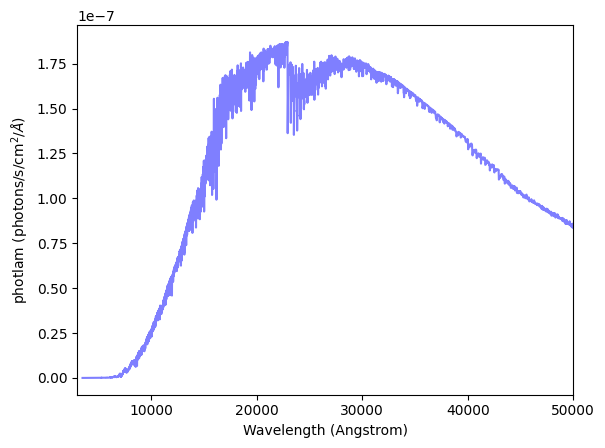

In [57]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(0.3e4, 5e4)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel(r'photlam $(\text{photons}/\text{s}/\text{cm}^2/\AA)$')

In [ ]:
energy = (const.h*const.c/wvs).to(u.erg)
files = sorted(glob.glob('data/rsg_grf/rsg.s*'))
spec =  np.loadtxt(files[-1], skiprows=4)
dwv, dfl = spec[:, 0], spec[:, 1]
de = spec[:, 4]

dist = 13*u.Mpc
flux_scale = ((1 * u.L_sun) / (4 * np.pi * dist**2)).to(u.erg/u.s/u.cm**2)
scale = 10**4.4

flux = (dfl/dwv)*u.erg/u.s/u.cm**2/u.Angstrom
waves = dwv*u.um
denergy = (const.h*const.c/waves).to(u.erg)

normalize = simpson(flux, x=waves.to(u.Angstrom))
scale_flux = scale * flux_scale * flux.value/normalize / u.Angstrom
dust_flux = de*scale_flux

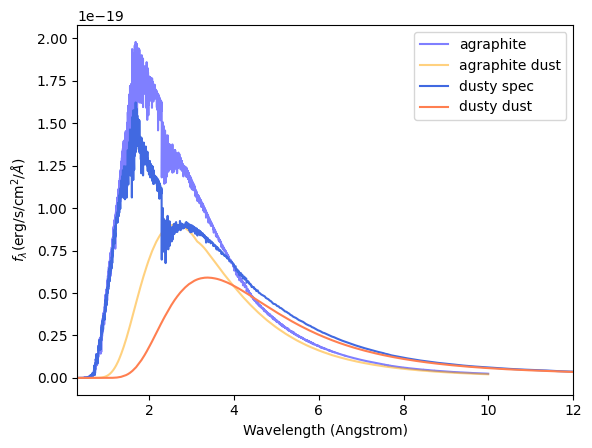

In [51]:
wvs = rsgspec.waveset
plt.plot(wvs/1e4, rsgspec(wvs)*energy, color = 'blue', alpha = 0.5, label = 'agraphite')
plt.plot(wvs/1e4, bbspec(wvs)*energy, color = 'orange', alpha = 0.5, label = 'agraphite dust')
plt.plot(waves, scale_flux, color = 'royalblue', label = 'dusty spec')
plt.plot(waves, dust_flux, color = 'coral', label = 'dusty dust')
plt.legend()
plt.xlim(0.3, 12)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel(r'$f_{\lambda} (\text{erg}/\text{s}/\text{cm}^2/\AA)$')
plt.savefig('plots/dusty_comp_grf.png', bbox_inches='tight')

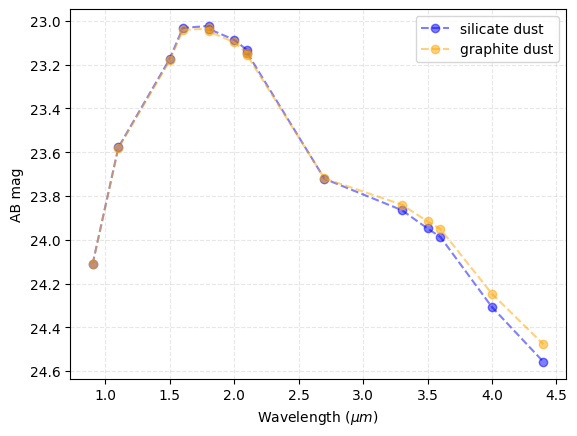

In [20]:
wvs = [float(i[1:3])/10 for i in filts]
mags_s2 = [rsgmag_s2[flt].value for flt in filts]
mags_g2 = [rsgmag_g2[flt].value for flt in filts]
plt.plot(wvs, mags_s2, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--', label = 'silicate dust')
plt.plot(wvs, mags_g2, color = 'orange', alpha = 0.5, marker = 'o', linestyle = '--', label = 'graphite dust')
plt.legend()
plt.grid(alpha = 0.3, linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()

In [6]:
params = ['lum', 'tau', 'temp']
filts = ['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']
modeldf = pd.DataFrame(columns=params+filts)
syn_rsg = rsg_phot()
rsg_temps = np.linspace(3400, 5000, 11) * u.K
taus = np.linspace(0.01, 5, 11)
lums = np.linspace(4, 5.5, 11) * u.Lsun
dust_model = 's2'

if os.path.exists(f'data/dolphot/ngc5643/ngc5643_marcs_{dust_model}.csv'):
    modeldf = pd.read_csv(f'data/dolphot/ngc5643/ngc5643_marcs_{dust_model}.csv')
else:
    for lum in tqdm(lums):
        for tau in taus:
            for temp in rsg_temps:
                try:
                    rsgmag = syn_rsg.compute_rsg_mag(filts, tau, lum, temp, 1000 * u.K, 12.474*u.Mpc, dust_model)
                    modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [i.value for i in rsgmag.values()]
                except:
                    modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [np.nan]*len(filts)
    modeldf.to_csv(f'data/dolphot/ngc5643/ngc5643_marcs_{dust_model}.csv', index=False)

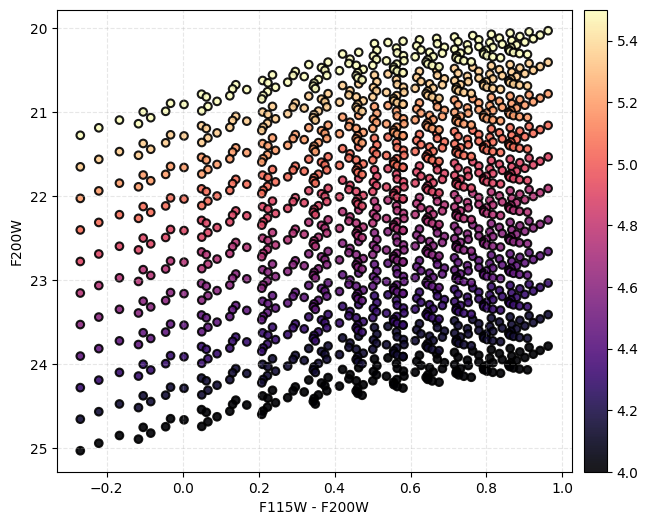

In [7]:
flt_1, flt_2 = 'f115w', 'f200w'
plt.figure(figsize = (8, 6))
plt.scatter(modeldf[flt_1]-modeldf[flt_2], modeldf[flt_2], marker='o', s=30, c=np.repeat(lums.value, 121),
            cmap='magma', edgecolors='black', lw=1.5, alpha=0.9)
plt.colorbar(pad = 0.02)
plt.xlabel(f'{flt_1.upper()} - {flt_2.upper()}')
plt.ylabel(f'{flt_2.upper()}')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, linestyle='--')

### GRAMS models

In [358]:
files = sorted(glob.glob('data/grams_ogrid/*txt'))

In [360]:
grid = np.loadtxt(files[0], skiprows=15)
wv, flux = grid[:, 0] * u.Angstrom, grid[:, 1] * u.erg/u.cm**2/u.s/u.Angstrom

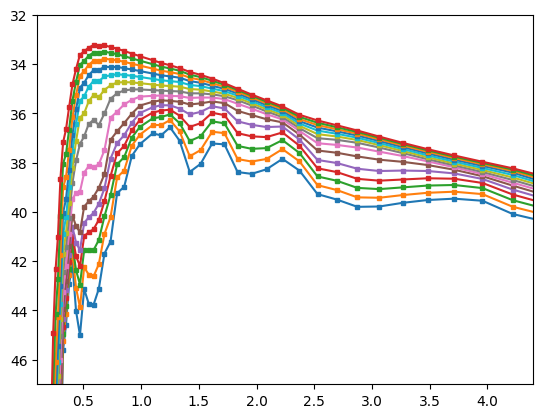

In [399]:
fig, ax = plt.subplots(1, 1)
for fl in files:
    grid = np.loadtxt(fl, skiprows=15)
    wv, flux = grid[:, 0] * u.Angstrom, grid[:, 1] * u.erg/u.cm**2/u.s/u.Angstrom
    ax.plot(wv.to(u.um), -2.5*np.log10(flux.value), marker = 's', markersize = 3)
    ax.set_xlim(0.1, 4.4)
    ax.set_ylim(32, 47)
# plt.yscale('log')
plt.gca().invert_yaxis()

### dolphot catalogs

In [8]:
cat = None
for fl in glob.glob('data/dolphot/ngc5643/proc/ngc5643_0_*.csv'):
    if cat is None:
        cat = pd.read_csv(fl)
    else:
        df_ = pd.read_csv(fl)
        cat = pd.concat([cat, df_])
cat.reset_index(inplace=True)

In [9]:
def lin(x, m, c):
    return m*x+c

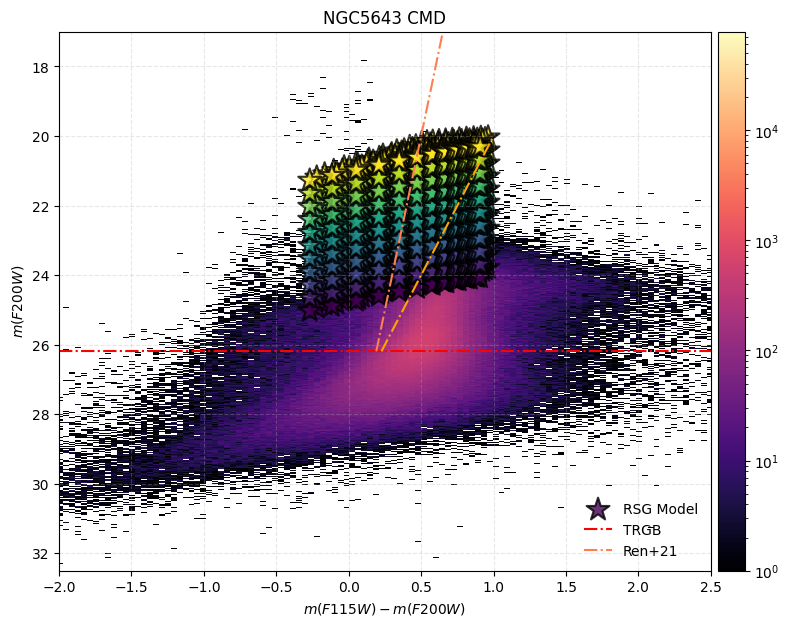

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']

hist = ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'magma')
ax.scatter(modeldf[f1.lower()] - modeldf[f2.lower()], modeldf[f2.lower()], marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.8, label = 'RSG Model')

ax.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
ax.set_ylim(32.5, 17)
plt.show()

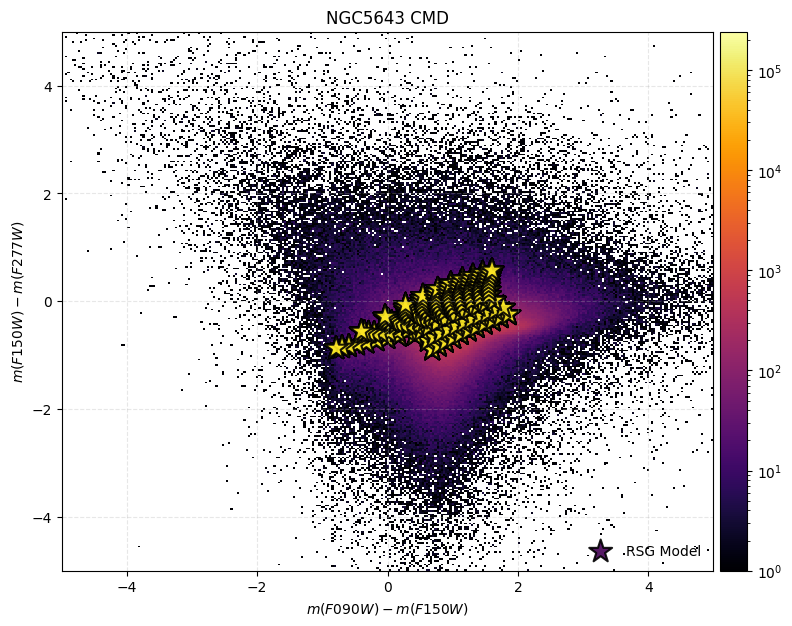

In [137]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2, f3 = 'F090W', 'F150W', 'F277W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag'] - cat[f3+'_mag']

hist = ax.hist2d(cl, m, bins = 5000, norm = 'log', cmap = 'inferno')
ax.scatter(modeldf[f1.lower()] - modeldf[f3.lower()], modeldf[f2.lower()] - modeldf[f3.lower()], marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2}) - m({f3})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.show()

In [407]:
jwst_wv = np.array([0.9, 1.15, 1.5, 1.64, 1.87, 2, 2.12, 2.77, 3, 3.35, 3.56, 3.6, 4.05, 4.44])

Text(0, 0.5, 'AB Mag')

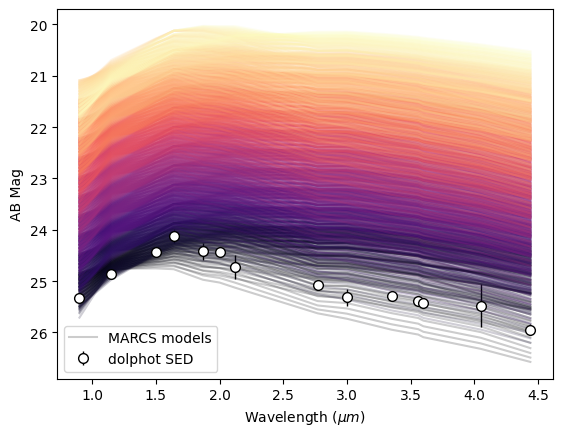

In [435]:
# rsg_mask = (m>lin(cl, -8.0, 25+3)) & (m<24) & (cl < 1.8)
rsg_mask = (m<25) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3))
idx = cat[rsg_mask].sample(1).index[0]
st = cat.loc[idx].to_numpy()
mag, magerr = st[7:21], st[21:]
nanmask = (mag>99) | (magerr>9)
mag[nanmask], magerr[nanmask] = np.nan, np.nan
fig, ax = plt.subplots(1, 1)
ax.errorbar(x=jwst_wv, y=mag, yerr=magerr, marker='o', markerfacecolor='white', markeredgecolor='black', 
            markersize=7, lw=0, ecolor='black', elinewidth=1, label = 'dolphot SED')

n_lines = 1331
c = np.arange(1, n_lines + 1)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.magma)
cmap.set_array([])

for i, midx in enumerate(modeldf.index):
    model_st = modeldf.iloc[midx][filts].to_numpy().flatten()
    if i==0:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2, label = 'MARCS models')
    else:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2)

plt.gca().invert_yaxis()
plt.legend()
plt.xlabel(r'Wavelength $(\mu m)$')
plt.ylabel('AB Mag')
# plt.savefig('plots/sed.png', bbox_inches = 'tight')

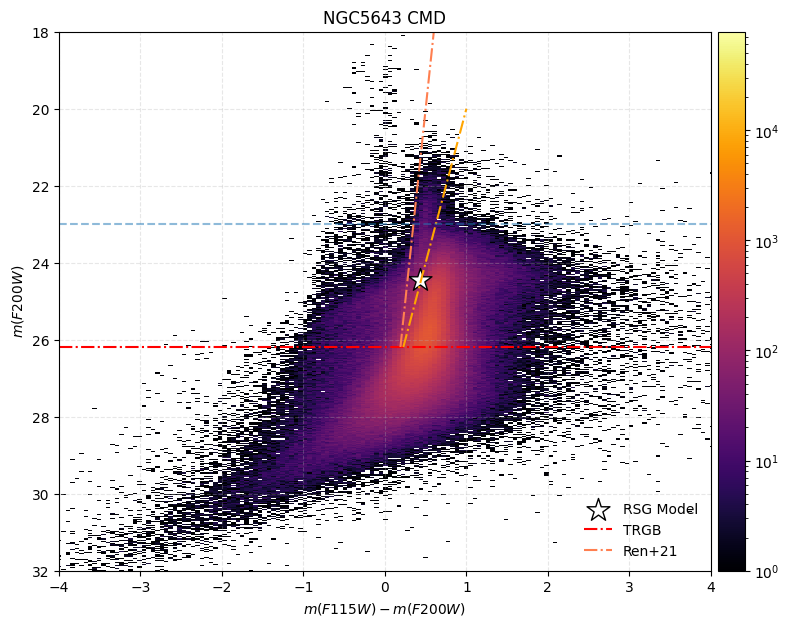

In [436]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']

hist = ax.hist2d(cl, m, bins = 3000, norm = 'log', cmap = 'inferno')
ax.scatter(cat.loc[idx]['F115W_mag']-cat.loc[idx]['F200W_mag'], cat.loc[idx]['F200W_mag'], marker='*', s=300, facecolor='white', edgecolor='black', alpha=1.0, label = 'RSG Model')

ax.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-4, 4)
ax.set_ylim(32, 18)
plt.axhline(23, linestyle='--', alpha=0.5)
plt.show()

In [437]:
rsg_mask.sum()

np.int64(15176)

### GP model

In [410]:
import george
from george import kernels
from sklearn.exceptions import ConvergenceWarning
import warnings

In [411]:
def fit_gp_model_george(wvs, mags, err, min_len_scale=1):

    # kernel = kernels.Matern52Kernel(metric = [min_len_scale**2], bounds = [[np.min(mags) - 5,np.max(mags)  + 5]])
    kernel = kernels.RationalQuadraticKernel(log_alpha=0.4, metric=min_len_scale) 
    gp_model = george.GP(kernel, solver=george.HODLRSolver, white_noise=np.log(0.01**2), fit_white_noise=True)

    with warnings.catch_warnings():
        warnings.filterwarnings(action="ignore", category=ConvergenceWarning)
        gp_model.compute(wvs, err)
    return gp_model

In [412]:
def plot_sed_with_gpmodel(wv, mag, magerr, gpmodel, savefilename=None):
    plt.figure()
    plt.errorbar(wv, mag, magerr, fmt='.', markersize=8, color='#0f084b', label = 'dolphot sed')

    x = np.atleast_2d(np.linspace(min(wv), max(wv), 500)).T
    y_pred, sigmasq = gpmodel.predict(mag, x, return_var=True)
    sigma = np.sqrt(sigmasq)

    plt.plot(x, y_pred, c='#26408b', label='GP model')
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([y_pred - 1.9600 * sigma, (y_pred + 1.9600 * sigma)[::-1]]),
             alpha=.5, fc='#a6cfd5', ec='None', label='95% confidence interval')

    plt.gca().invert_yaxis()
    plt.xlabel(r'Wavelength $(\mu m)$')
    plt.ylabel('AB Mag')
    # plt.ylim(26.5, 24)
    plt.grid(alpha = 0.3, linestyle = '--')
    plt.savefig(savefilename, bbox_inches='tight')
    # plt.show()

In [438]:
mid, chisq = [], []
nwmask = np.isnan(mag)
for id_ in modeldf.index:
    model_magnitudes = modeldf.loc[id_][['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']].to_numpy()
    chsq = np.sum((model_magnitudes[~nwmask] - mag[~nwmask])**2)
    mid.append(id_); chisq.append(chsq)
print(min(chisq))

0.4496006688751862


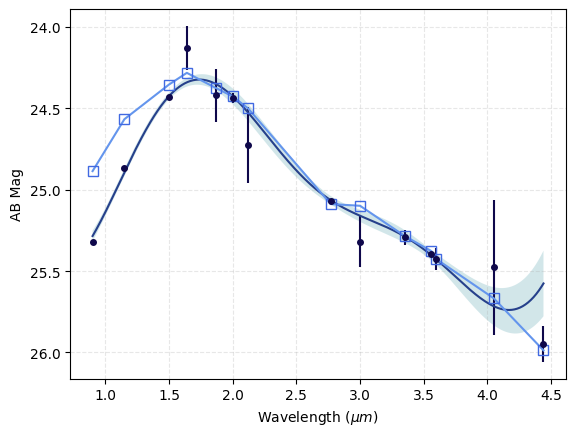

In [439]:
gpmag, gpmagerr = mag[~np.isnan(mag)], magerr[~np.isnan(magerr)]
waves = jwst_wv[~np.isnan(mag)]
gpmodel = fit_gp_model_george(waves, gpmag, gpmagerr, min_len_scale=2.5)
plot_sed_with_gpmodel(waves, gpmag, gpmagerr, gpmodel, 'plots/sed_george.png')
best_model = modeldf.loc[mid[np.argmin(chisq)]][['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']].to_numpy()
plt.plot(jwst_wv, best_model, marker = 's', fillstyle='none', markeredgecolor = 'royalblue', color = 'cornflowerblue', markersize = 7)
# plt.savefig('plots/marcs_fit7.png', bbox_inches='tight')

In [440]:
modeldf.loc[mid[np.argmin(chisq)]][['lum', 'tau', 'temp']]

lum        4.00
tau        0.01
temp    4040.00
Name: 4, dtype: float64

### PCA

In [11]:
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic
from sklearn.svm import SVC

In [12]:
pca = PCA(n_components=6)
ica = FastICA(n_components=5)
std_scaler = StandardScaler()
mmax_scaler = MinMaxScaler()

In [20]:
fls = [i.upper()+'_mag' for i in filts]
subdf = cat[(m < 26)][fls] # & (cl > -0.5) & (cl < 1.5)
subdf[subdf > 99] = np.nan
subdf = subdf.dropna()

In [21]:
model_mags = modeldf[filts].to_numpy().T
# stacked_mags = copy.copy(mags)
stacked_mags = np.concat([subdf.values, modeldf[filts].values]).T
icm = np.array(len(subdf)*[True] + 1331*[False])

scaled_mags = mmax_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
pca.fit(fit_input)

PCA(n_components=6)

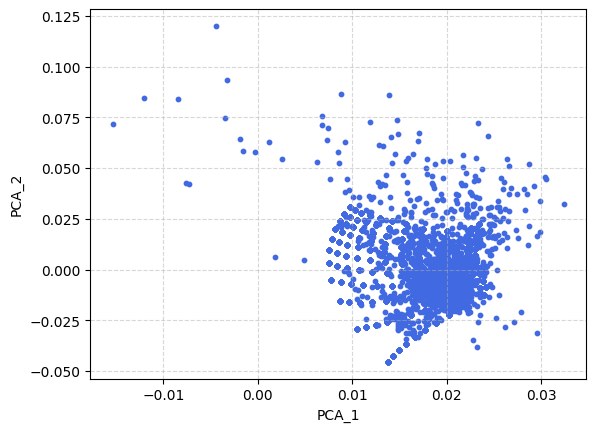

In [78]:
plt.scatter(pca.components_[0], pca.components_[1], s = 10, color = 'royalblue')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

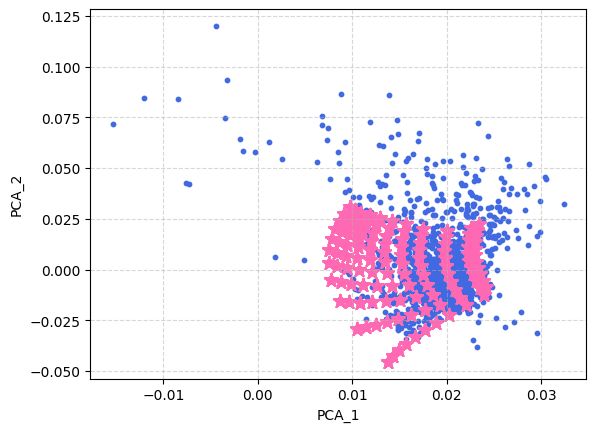

In [79]:
plt.scatter(pca.components_[0][icm], pca.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[0][~icm], pca.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

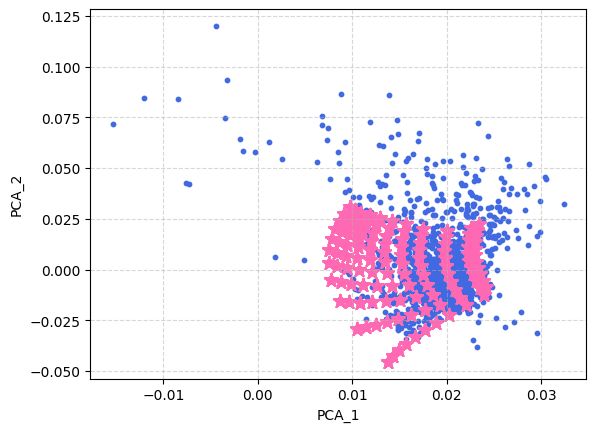

In [69]:
pcacomp0, pcacomp1 = 0, 1
plt.scatter(pca.components_[pcacomp0][icm], pca.components_[pcacomp1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[pcacomp0][~icm], pca.components_[pcacomp1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [ ]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
smg = []
stacked_mags = np.hstack([mags, model_mags])

mask = (stacked_mags[0] < 80) & (stacked_mags[1] < 80) & (stacked_mags[2] < 80)
smg.append(stacked_mags[0][mask])
smg.append(stacked_mags[1][mask])
smg.append(stacked_mags[2][mask])
smg = np.array(smg)
stacked_mags = smg
icm = np.array(len(mags[0])*[True] + len(model_mags[0])*[False])[mask]

scaled_mags = std_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
ica.fit(fit_input)

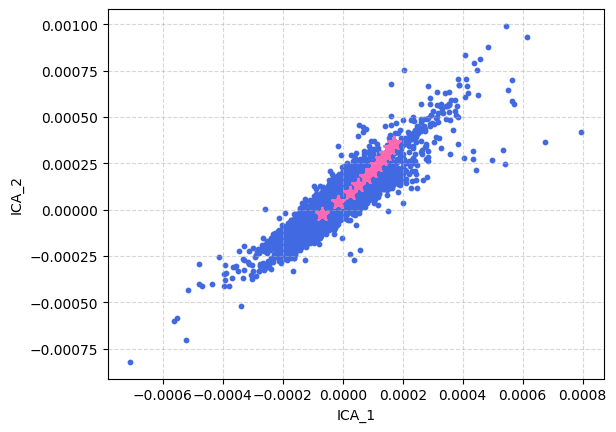

In [79]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

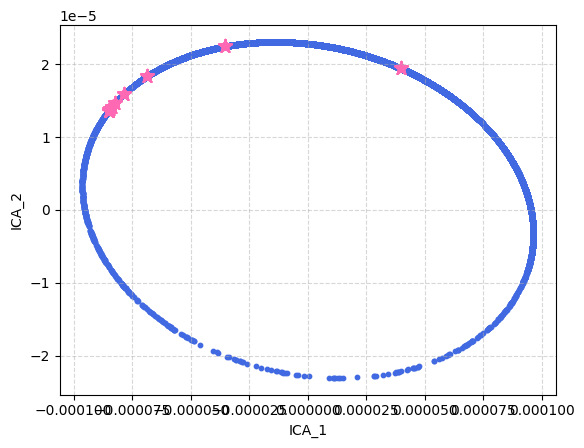

In [76]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [22]:
from sklearn.cluster import DBSCAN, HDBSCAN

In [23]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(stacked_mags.T)

In [24]:
np.unique(labels)

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140])

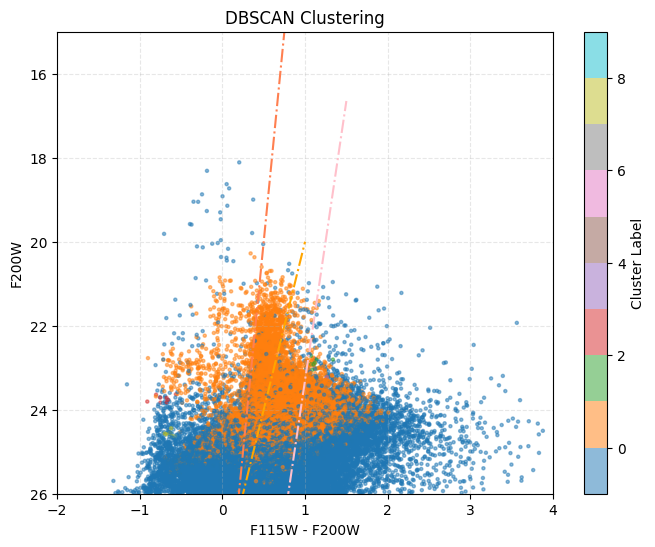

In [25]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(stacked_mags.T[icm][:, 1][(labels[icm]<10)] - stacked_mags.T[icm][:, 5][(labels[icm]<10)], 
                      stacked_mags.T[icm][:, 5][(labels[icm]<10)], 
                      c=labels[icm][(labels[icm]<10)], cmap = 'tab10', s=5, alpha=0.5)
# plt.scatter(stacked_mags.T[~icm][:, 1] - stacked_mags.T[~icm][:, 5], stacked_mags.T[~icm][:, 5], color='orange', marker = 's', s=2, alpha=0.7)

plt.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
plt.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
plt.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')
plt.plot(np.linspace(0.22625, 1.5, 100), lin(np.linspace(0.22625, 1.5, 100), -13.3, 24.6+12), linestyle='-.', color = 'pink')

plt.xlabel('F115W - F200W')
plt.ylabel('F200W')
plt.title('DBSCAN Clustering')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(alpha=0.3, linestyle='--')
plt.xlim(-2, 4)
plt.ylim(26, 15)
plt.show()

In [27]:
(labels[icm] == 0).sum()

np.int64(69195)

In [45]:
cat.loc[subdf[labels[icm] == 2].index].to_csv('data/dolphot/ngc5643/dbscan_rsg.csv', index=False)

In [302]:
fls = [i.upper()+'_mag' for i in filts]
rsg_subdf = cat[(m<25) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3))][fls]
rsg_subdf[rsg_subdf > 99] = np.nan
rsg_subdf = rsg_subdf.dropna()
rlb = [0]*len(rsg_subdf)

fls = [i.upper()+'_mag' for i in filts]
agb_subdf = cat[(m<26) & (m > lin(cl, -8.0, 25+6)) & (cl < 1.0)][fls]
agb_subdf[agb_subdf > 99] = np.nan
agb_subdf = agb_subdf.dropna()
agb_subdf = agb_subdf.sample(10000)
alb = [1]*len(agb_subdf)

stacked_mags = pd.concat([rsg_subdf, agb_subdf]).values
X, y = stacked_mags, np.array(rlb+alb)

In [303]:
clf = SVC(probability=True)
clf.fit(X, y)
clf.score(X, y)

0.9998837209302326

In [304]:
fls = [i.upper()+'_mag' for i in filts]
subdf = cat[(m<26)][fls]
subdf[subdf > 99] = np.nan
subdf = subdf.dropna()
# subdf = subdf.sample(10000)

In [305]:
probs = clf.predict_proba(subdf.values)
rp, ap = probs[:, 0], probs[:, 1]

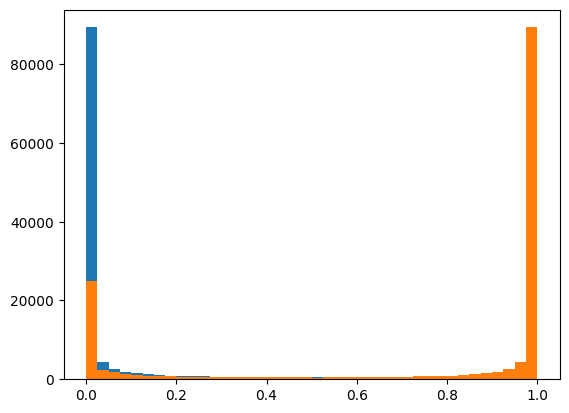

In [306]:
plt.hist(rp, bins = 40)
_ = plt.hist(ap, bins = 40)

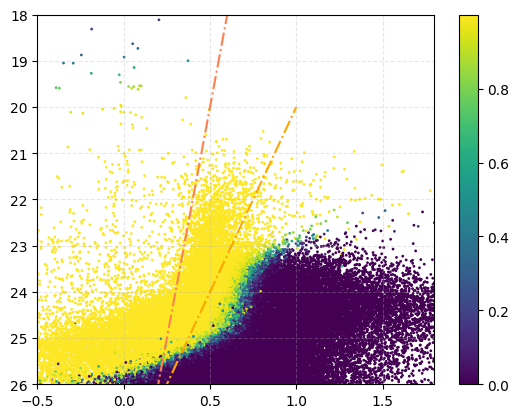

In [309]:
plt.scatter((subdf['F115W_mag'] - subdf['F200W_mag']), subdf['F200W_mag'], s=1.0, c = rp)
plt.colorbar()

# plt.scatter(cl, m, color = 'gray', alpha = 0.2, s = 0.01)
plt.axhline(26.19, color = 'red', label='TRGB', linestyle = '-.')
plt.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
plt.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -8.0, 25+3), linestyle='-.', color = 'orange')

plt.xlim(-0.5, 1.8)
plt.ylim(26, 18)

plt.grid(alpha=0.3, linestyle='--')